In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# =========================
# COMPLETE BRAIN CANCER CNN
# ONE CELL FULL PIPELINE
# =========================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1. DATASET PATH (KAGGLE)
# -------------------------
ROOT = "/kaggle/input/brain-tumor-mri-dataset"

# auto-detect nested folder
lvl1 = os.listdir(ROOT)[0]
lvl2 = os.listdir(os.path.join(ROOT, lvl1))[0]
BASE_DIR = os.path.join(ROOT, lvl1, lvl2)

print("✅ FINAL IMAGE PATH:", BASE_DIR)
print("📂 CLASSES:", os.listdir(BASE_DIR))

# -------------------------
# 2. TRANSFORMS
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# -------------------------
# 3. LOAD DATASET
# -------------------------
dataset = datasets.ImageFolder(BASE_DIR, transform=transform)
class_names = dataset.classes
print("✅ Classes:", class_names)
print("✅ Total Images:", len(dataset))

# -------------------------
# 4. TRAIN / TEST SPLIT
# -------------------------
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

# -------------------------
# 5. MODEL (BEST ACCURACY)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

model = model.to(device)

# -------------------------
# 6. LOSS & OPTIMIZER
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0003)

# -------------------------
# 7. TRAINING
# -------------------------
epochs = 10
best_acc = 0

for epoch in range(epochs):
    model.train()
    correct, total, train_loss = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"""
Epoch {epoch+1}
Train Loss: {train_loss/len(train_loader):.4f}
Train Acc : {train_acc:.4f}
Val Acc   : {val_acc:.4f}
""")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_brain_cancer_model.pth")

# -------------------------
# 8. CONFUSION MATRIX
# -------------------------
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# 9. CLASSIFICATION REPORT
# -------------------------
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print("✅ TRAINING COMPLETE | MODEL SAVED AS best_brain_cancer_model.pth")

✅ FINAL IMAGE PATH: /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
📂 CLASSES: ['Tr-pi_0532.jpg', 'Tr-pi_0282.jpg', 'Tr-pi_1401.jpg', 'Tr-pi_0914.jpg', 'Tr-pi_0691.jpg', 'Tr-pi_0972.jpg', 'Tr-pi_0818.jpg', 'Tr-pi_0463.jpg', 'Tr-pi_0930.jpg', 'Tr-pi_1323.jpg', 'Tr-pi_1347.jpg', 'Tr-pi_1354.jpg', 'Tr-pi_0704.jpg', 'Tr-pi_0789.jpg', 'Tr-pi_1445.jpg', 'Tr-pi_0605.jpg', 'Tr-pi_0882.jpg', 'Tr-pi_1274.jpg', 'Tr-pi_0339.jpg', 'Tr-pi_1271.jpg', 'Tr-pi_0458.jpg', 'Tr-pi_1283.jpg', 'Tr-pi_0266.jpg', 'Tr-pi_0115.jpg', 'Tr-pi_0758.jpg', 'Tr-pi_0946.jpg', 'Tr-pi_0473.jpg', 'Tr-pi_1204.jpg', 'Tr-pi_1084.jpg', 'Tr-pi_0199.jpg', 'Tr-pi_0989.jpg', 'Tr-pi_0822.jpg', 'Tr-pi_0367.jpg', 'Tr-pi_0951.jpg', 'Tr-pi_1358.jpg', 'Tr-pi_0670.jpg', 'Tr-pi_0575.jpg', 'Tr-pi_0729.jpg', 'Tr-pi_1200.jpg', 'Tr-pi_1057.jpg', 'Tr-pi_0588.jpg', 'Tr-pi_0185.jpg', 'Tr-pi_0806.jpg', 'Tr-pi_0980.jpg', 'Tr-pi_0935.jpg', 'Tr-pi_0759.jpg', 'Tr-pi_1139.jpg', 'Tr-pi_1310.jpg', 'Tr-pi_0038.jpg', 'Tr-pi_0802.jpg', 'Tr-pi_1384

FileNotFoundError: Couldn't find any class folder in /kaggle/input/brain-tumor-mri-dataset/Training/pituitary.

✅ FINAL IMAGE PATH FOUND:
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer
📂 CLASS FOLDERS: ['brain_tumor', 'brain_glioma', 'brain_menin']
🧠 Total Images Found: 6056


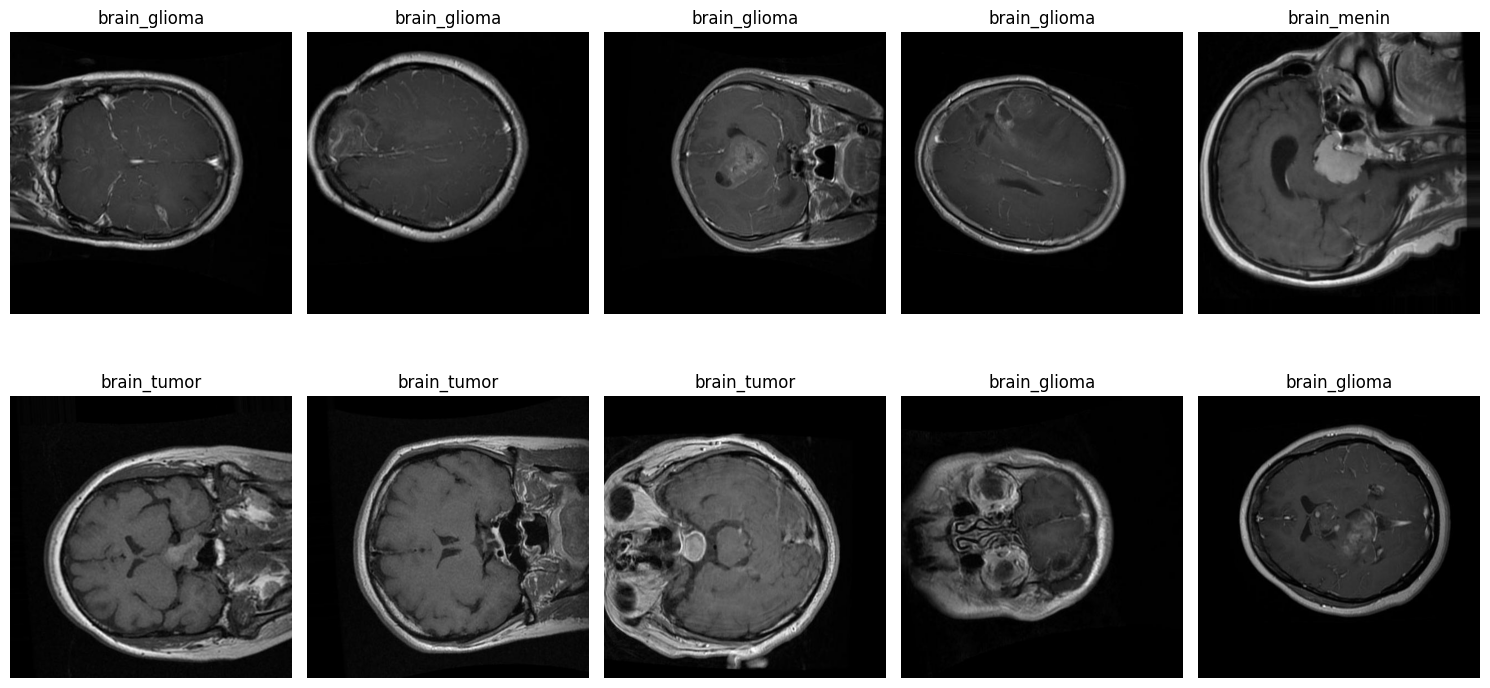

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# AUTO-DETECT IMAGE FOLDER
# =========================
ROOT = "/kaggle/input/brain-cancer-mri-dataset"

def find_image_root(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if len(dirnames) >= 3:   # likely class folders
            return dirpath
    return None

BASE_DIR = find_image_root(ROOT)

print("✅ FINAL IMAGE PATH FOUND:")
print(BASE_DIR)
print("📂 CLASS FOLDERS:", os.listdir(BASE_DIR))

# =========================
# COLLECT ALL IMAGE PATHS
# =========================
image_paths = []

for cls in os.listdir(BASE_DIR):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            image_paths.append((os.path.join(cls_path, img), cls))

print("🧠 Total Images Found:", len(image_paths))

# =========================
# SHOW 10 RANDOM IMAGES
# =========================
samples = random.sample(image_paths, 10)

plt.figure(figsize=(15,8))
for i, (img_path, label) in enumerate(samples):
    img = Image.open(img_path)
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


100%|██████████| 144M/144M [00:00<00:00, 196MB/s]

Extracting files...


✅ Dataset downloaded at: /root/.cache/kagglehub/datasets/orvile/brain-cancer-mri-dataset/versions/2
📂 Classes: ['brain_glioma', 'brain_menin', 'brain_tumor']
✅ Classes: ['brain_glioma', 'brain_menin', 'brain_tumor']
✅ Total Images: 6056


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...


Epoch 10 | Train Acc: 0.9942 | Val Acc: 0.9893



Epoch 11/12: 100%|██████████| 152/152 [00:34<00:00,  4.37it/s]



Epoch 11 | Train Acc: 0.9915 | Val Acc: 0.9884



Epoch 12/12: 100%|██████████| 152/152 [00:34<00:00,  4.41it/s]



Epoch 12 | Train Acc: 0.9936 | Val Acc: 0.9868



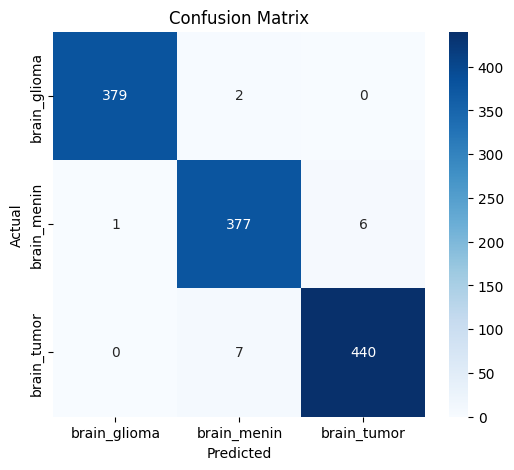

              precision    recall  f1-score   support

brain_glioma       1.00      0.99      1.00       381
 brain_menin       0.98      0.98      0.98       384
 brain_tumor       0.99      0.98      0.99       447

    accuracy                           0.99      1212
   macro avg       0.99      0.99      0.99      1212
weighted avg       0.99      0.99      0.99      1212

✅ DONE | MODEL SAVED AS best_brain_cancer_model.pth


In [ ]:
# ==============================
# BRAIN CANCER CNN | kagglehub direct
# ==============================

!pip install -q kagglehub
import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1. DOWNLOAD DATASET
# -------------------------
dataset_path = kagglehub.dataset_download("orvile/brain-cancer-mri-dataset")
print("✅ Dataset downloaded at:", dataset_path)

# auto-detect inner folder
BASE_DIR = None
for root_dir, dirs, files in os. Iswalk(dataset_path):
    if len(dirs) > 1:  # likely class folders
        BASE_DIR = root_dir
        break

if BASE_DIR is None:
    raise Exception("❌ Dataset folder not found")

print("📂 Classes:", os.listdir(BASE_DIR))

# -------------------------
# 2. TRANSFORMS
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------------
# 3. LOAD DATASET
# -------------------------
dataset = datasets.ImageFolder(BASE_DIR, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

print("✅ Classes:", class_names)
print("✅ Total Images:", len(dataset))

# -------------------------
# 4. TRAIN/TEST SPLIT
# -------------------------
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

# -------------------------
# 5. MODEL (ResNet18 + FINETUNE)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)

# freeze all layers first
for param in model.parameters():
    param.requires_grad = False
# unfreeze last block
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
model = model.to(device)

# -------------------------
# 6. FOCAL LOSS (FN REDUCTION)
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")
    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt)**self.gamma * ce_loss).mean()

criterion = FocalLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# -------------------------
# 7. TRAINING
# -------------------------
epochs = 12
best_acc = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = total = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    model.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"\nEpoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}\n")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_brain_cancer_model.pth")

# -------------------------
# 8. CONFUSION MATRIX
# -------------------------
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# 9. REPORT
# -------------------------
print(classification_report(y_true, y_pred, target_names=class_names))
print("✅ DONE | MODEL SAVED AS best_brain_cancer_model.pth")

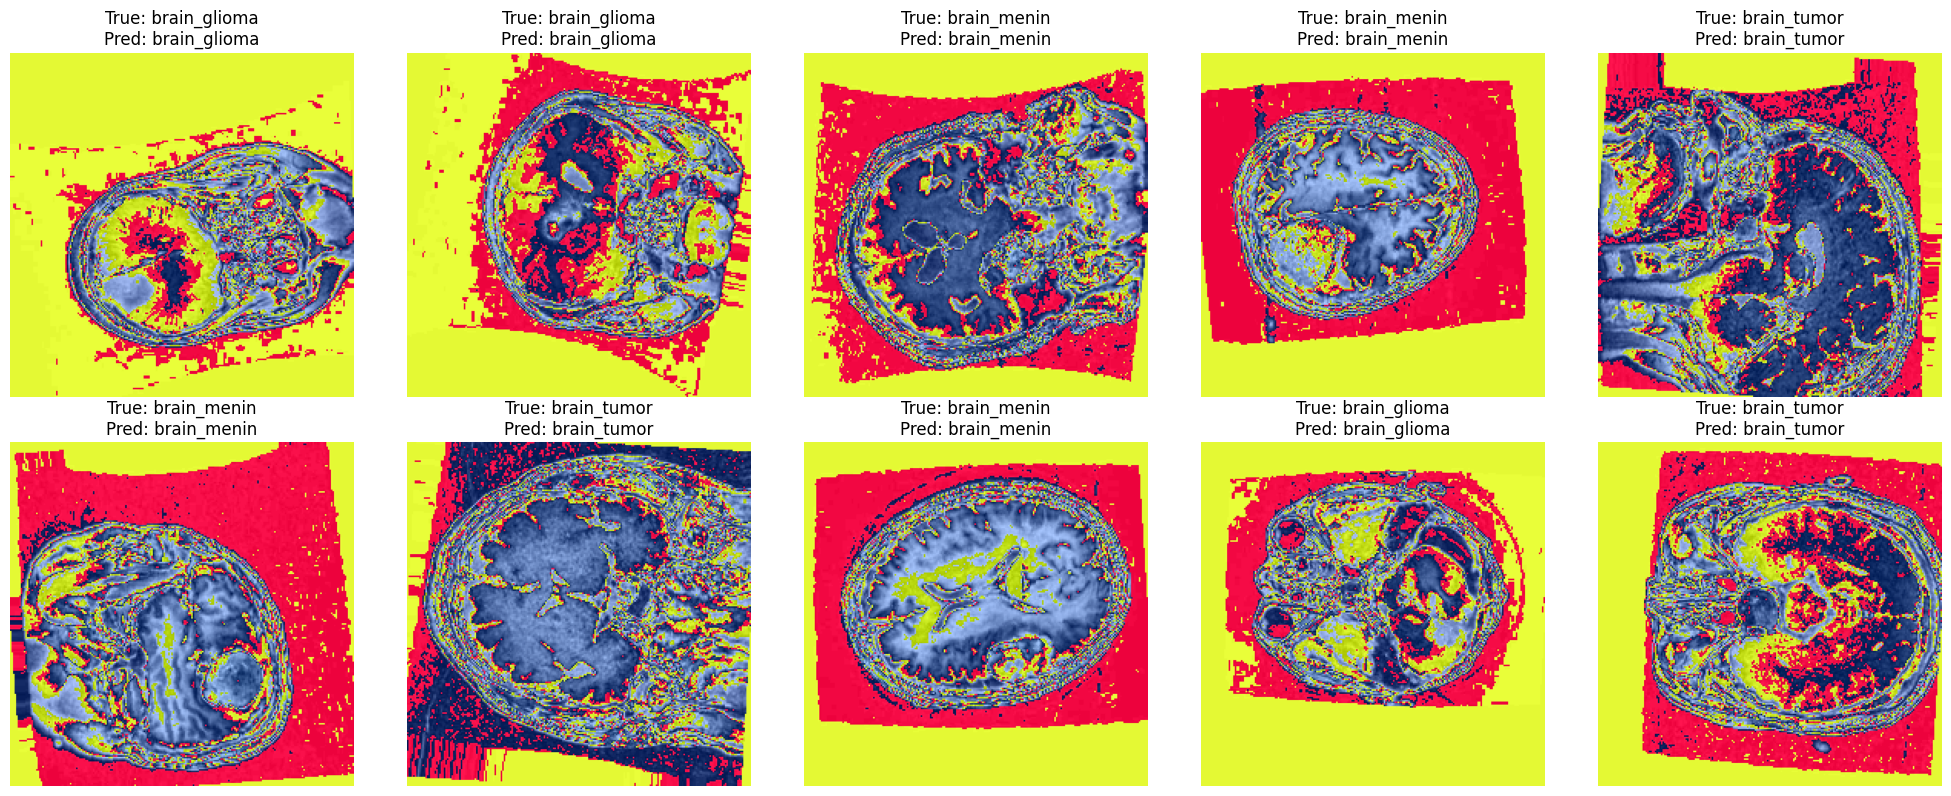

In [ ]:
import random
import matplotlib.pyplot as plt
import torchvision

# -------------------------
# 1. SELECT 10 RANDOM IMAGES FROM TEST SET
# -------------------------
model.eval()
images, labels = next(iter(DataLoader(test_ds, batch_size=len(test_ds))))
images, labels = images.to(device), labels.to(device)

indices = random.sample(range(len(images)), 10)
sample_imgs = images[indices]
sample_labels = labels[indices]

# -------------------------
# 2. PREDICT
# -------------------------
with torch.no_grad():
    outputs = model(sample_imgs)
    _, preds = torch.max(outputs, 1)

# -------------------------
# 3. DISPLAY
# -------------------------
fig, axes = plt.subplots(2,5, figsize=(20,8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = sample_imgs[i].cpu()
    img = torchvision.transforms.functional.to_pil_image(img)
    true_label = class_names[sample_labels[i].item()]
    pred_label = class_names[preds[i].item()]
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🧠 Predicted Class: brain_menin


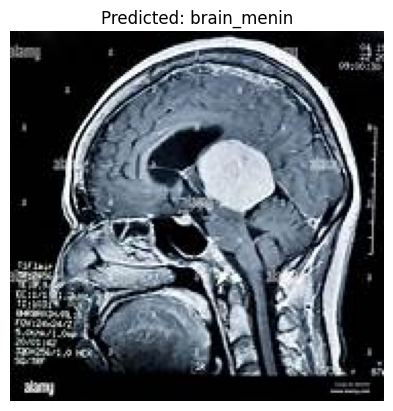

In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import torch

# -------------------------
# 1. LOAD MODEL (BEST SAVED MODEL)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

model.load_state_dict(torch.load("best_brain_cancer_model.pth", map_location=device))
model = model.to(device)
model.eval()

# -------------------------
# 2. IMAGE TRANSFORM
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------------
# 3. LOAD YOUR IMAGE
# -------------------------
image_path = "/kaggle/working/sample_mri.jpg"  # <--- replace with your image path
img = Image.open("/content/OIP.jpg").convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension

# -------------------------
# 4. PREDICTION
# -------------------------
with torch.no_grad():
    output = model(img_tensor)
    _, pred = torch.max(output, 1)
    predicted_class = class_names[pred.item()]

print(f"🧠 Predicted Class: {predicted_class}")

# -------------------------
# 5. DISPLAY IMAGE
# -------------------------
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()